# Multi-Perspective Segmentation Project

## Data Mining Project
------
**Group 12:**

- Luis Mendes 20221949
- Margarida Mourives 20221809
- Simon Sazonov 20221689 
- Veronica Mendes 20221945

----

## Summary

This notebook combines **Value-based**, **Demographic** and **Behavioral** perspectives to create a unified customer segmentation.


## Imports

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings

from sklearn.preprocessing import  MinMaxScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering


warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## Load Data

First, we need to load the datasets for each perspective.

In [153]:
demographic = pd.read_csv('demographic_clusters.csv')
behavioral = pd.read_csv('behavioral_clusters_year.csv')
behavioral_m = pd.read_csv('behavioral_clusters_month.csv')
value_based = pd.read_csv('value_based_clusters.csv')

df_AIAI_Master_Complete = pd.read_csv('../data/DM_AIAI_MasterCustomerDB.csv', index_col=0,
                                      parse_dates=['EnrollmentDateOpening', 'CancellationDate'])
df_AIAI_Master = df_AIAI_Master_Complete.copy()

Let's look at the cluster distribution in each perspective.

In [154]:
print(demographic['Demographic_Cluster_Name'].nunique())
print(behavioral['Behavioral_Year_Cluster_Name'].nunique())
print(behavioral_m['Behavioral_Month_Cluster_Name'].nunique())
print(value_based['Value_Based_Cluster_Name'].nunique())

4
9
15
9


The Demographic perspective contains 4 clusters, Value-Based has 9, Behavioral (Yearly) has 9, and Behavioral (Monthly) with 15 clusters. If we were to consider every possible intersection of these segments, it would result in approximately 4,860 unique combinations.

##  Merge Perspectives
We join the perspectives using a common identifier (Loyalty#).

In [155]:
df_multi_perspective = (df_AIAI_Master_Complete
             .merge(demographic, on='Loyalty#', how='inner')
             .merge(behavioral, on='Loyalty#', how='inner')
             .merge(behavioral_m, on='Loyalty#', how='inner')
             .merge(value_based, on='Loyalty#', how='inner')).copy()
df_multi_perspective.head()

,Loyalty#,First Name,Last Name,Customer Name,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,Re_engaged_people,Days_with_us,Days_until_reengagement,Total_NumFlights,Total_DistanceKM,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining,Recency_Days,Total_NumFlights_2019,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2019,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2019,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2019,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12,Demographic_Cluster_Name,Behavioral_Year_Cluster_Name,Behavioral_Month_Cluster_Name,Value_Based_Cluster_Name
0,480934,Cecilia,Householder,Cecilia Householder,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,False,1049,NaN,191.0,497375.0,29.319372,362.1394,29.0,59.0,64.0,68.0,116079.0,128976.0,252320.0,28.813559,29.687500,29.411765,94.4694,104.95,162.72,2.0,8.0,2.0,13.0,32.0,24.0,30.0,31.0,17.0,8.0,15.0,9.0,25173.0,65501.0,12324.0,4840.0,69191.0,43891.0,49709.0,44944.0,44545.0,70952.0,21244.0,45061.0,0.000000,25.000000,100.000000,23.076923,31.250000,0.000000,0.0,35.483871,58.823529,50.000000,73.333333,33.333333,25.1700,65.4939,12.3200,4.8400,69.1890,43.8785,49.7040,44.9366,44.5399,33.8046,-24.3761,-7.3610,High-Income East,Stable average travelers\n(Loyal),Avr|Mar Companion\r\n(Less travel on mar),Fly fanatics
1,549612,Dayle,Menez,Dayle Menez,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,2019-03-09,NaT,3839.61,Standard,False,1027,NaN,279.0,389939.0,11.469534,165.2639,29.0,89.0,99.0,91.0,127972.0,142191.0,119776.0,7.865169,8.080808,18.681319,67.8339,75.33,22.10,24.0,17.0,32.0,10.0,42.0,12.0,36.0,36.0,10.0,28.0,21.0,11.0,26197.0,26125.0,28793.0,9958.0,58007.0,3077.0,39929.0,76785.0,24325.0,33704.0,35889.0,27150.0,25.000000,0.000000,0.000000,30.000000,0.000000,41.666667,25.0,25.000000,0.000000,0.000000,0.000000,0.000000,-0.6498,26.1250,28.7843,9.9500,57.9989,3.0700,-157.8262,76.7735,24.3200,33.6881,35.8801,27.1500,Low-Income West,Formers Points accumulator\n(2020),Avr|Point Acumulator\r\n(No companions),Fly fanatics
2,429460,Necole,Hannon,Necole Hannon,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0

In [156]:
df_multi_perspective.set_index('Loyalty#', inplace=True)

In [157]:
df_multi_perspective.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 90 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   First Name                             16572 non-null  object        
 1   Last Name                              16572 non-null  object        
 2   Customer Name                          16572 non-null  object        
 3   Province or State                      16572 non-null  object        
 4   City                                   16572 non-null  object        
 5   Latitude                               16572 non-null  float64       
 6   Longitude                              16572 non-null  float64       
 7   Postal code                            16572 non-null  object        
 8   Gender                                 16572 non-null  object        
 9   Education                              16572 non-null  objec

We are going to remove this columns from the dataset, because they are not to be used, since some of them are not important for profiling or redundant.

In [158]:
# list of columns to remove
cols_to_remove = ['First Name', 'Last Name', 'Customer Name', 'Postal code',  
                  'EnrollmentDateOpening', 'CancellationDate', 'EnrollmentType','Re_engaged_people',
                  'Total_NumFlights_2019', 'Total_DistanceKM_2019', 'Perc_Flights_With_Companions_2019', 
                  'Dollar_Cost_Points_Remaining_2019',]

# Drop them 
df_multi_perspective.drop(inplace=True,columns=cols_to_remove)

In [159]:
df_multi_perspective.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 78 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Province or State                      16572 non-null  object 
 1   City                                   16572 non-null  object 
 2   Latitude                               16572 non-null  float64
 3   Longitude                              16572 non-null  float64
 4   Gender                                 16572 non-null  object 
 5   Education                              16572 non-null  object 
 6   Location Code                          16572 non-null  object 
 7   Income                                 16572 non-null  float64
 8   Marital Status                         16572 non-null  object 
 9   LoyaltyStatus                          16572 non-null  object 
 10  Customer Lifetime Value                16572 non-null  float64
 11  D

## Outliers

We will apply an outlier handling strategy using the Interquartile Range (IQR) method. Data points falling beyond 3 times the IQR (extreme outliers) will be capped for the variables previously proposed in each perspective.

In [160]:
columns_to_remove = ['Customer Lifetime Value',
                     'Dollar_Cost_Points_Remaining_month_1','Dollar_Cost_Points_Remaining_month_2',
                     'Dollar_Cost_Points_Remaining_month_3','Dollar_Cost_Points_Remaining_month_4',
                     'Dollar_Cost_Points_Remaining_month_5','Dollar_Cost_Points_Remaining_month_6',
                     'Dollar_Cost_Points_Remaining_month_7','Dollar_Cost_Points_Remaining_month_8',
                     'Dollar_Cost_Points_Remaining_month_9', 'Dollar_Cost_Points_Remaining_month_10', 
                     'Dollar_Cost_Points_Remaining_month_11', 'Dollar_Cost_Points_Remaining_month_12']

for col in columns_to_remove:
   q1 = df_multi_perspective[col].quantile(0.25)
   q3 = df_multi_perspective[col].quantile(0.75)
   iqr = q3 - q1
   lower_extreme = q1 - 3 * iqr
   upper_extreme = q3 + 3 * iqr

   df_multi_perspective[col] = df_multi_perspective[col].clip(lower=lower_extreme, upper=upper_extreme)

We will apply a cap of 365 on Rencency.

In [161]:
df_multi_perspective['Recency_Days'] = df_multi_perspective['Recency_Days'].clip(upper=365)

We will apply a floor of 0 to 'Dollar Cost Points Remaining,' as it is impossible to utilize more points than the total amount allocated.

In [162]:
df_multi_perspective['Dollar_Cost_Points_Remaining'] = df_multi_perspective['Dollar_Cost_Points_Remaining'].clip(lower=0)

In [163]:
df_multi_perspective.head()

,Province or State,City,Latitude,Longitude,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,Customer Lifetime Value,Days_with_us,Days_until_reengagement,Total_NumFlights,Total_DistanceKM,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining,Recency_Days,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12,Demographic_Cluster_Name,Behavioral_Year_Cluster_Name,Behavioral_Month_Cluster_Name,Value_Based_Cluster_Name
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
480934,Ontario,Toronto,43.653225,-79.383186,female,Bachelor,Urban,70146.0,Married,Star,3839.14,1049,NaN,191.0,497375.0,29.319372,362.1394,29.0,64.0,68.0,128976.0,252320.0,29.687500,29.411765,104.95,162.72,2.0,8.0,2.0,13.0,32.0,24.0,30.0,31.0,17.0,8.0,15.0,9.0,25173.0,65501.0,12324.0,4840.0,69191.0,43891.0,49709.0,44944.0,44545.0,70952.0,21244.0,45061.0,0.000000,25.000000,100.000000,23.076923,31.250000,0.000000,0.0,35.483871,58.823529,50.000000,73.333333,33.333333,25.1700,65.4939,12.3200,4.8400,69.1890,43.8785,49.7040,44.9366,44.5399,33.8046,-24.3761,-7.3610,High-Income East,Stable average travelers\n(Loyal),Avr|Mar Companion\r\n(Less travel on mar),Fly fanatics
549612,Alberta,Edmonton,53.544388,-113.490930,male,College,Rural,0.0,Divorced,Star,3839.61,1027,NaN,279.0,389939.0,11.469534,165.2639,29.0,99.0,91.0,142191.0,119776.0,8.080808,18.681319,75.33,22.10,24.0,17.0,32.0,10.0,42.0,12.0,36.0,36.0,10.0,28.0,21.0,11.0,26197.0,26125.0,28793.0,9958.0,58007.0,3077.0,39929.0,76785.0,24325.0,33704.0,35889.0,27150.0,25.000000,0.000000,0.000000,30.000000,0.000000,41.666667,25.0,25.000000,0.000000,0.000000,0.000000,0.000000,-0.6498,26.1250,28.7843,9.9500,57.9989,3.0700,-142.9017,76.7735,24.3200,33.6881,35.8801,27.1500,Low-Income West,Formers Points accumulator\n(2020),Avr|Point Acumulator\r\n(No companions),Fly fanatics
429460,British Columbia,Vancouver,49.282730,-123.120740,male,College,Urban,0.0,Single,Star,3839.75,1274,NaN,120.0,229821.0,33.333333,174.9763,363.0,60.0,6.0,108547.0,23583.0,35.000000,0.000000,79.66,23.58,21.0,8.0,15.0,0.0,23.0,0.0,0.0,21.0,15.0,0.0,15.0,2.0,66764.0,6097.0,30356.0,0.0,6110.0,0.0,0.0,16881.0,56823.0,0.0,1030.0,45760.0,0.000000,75.000000,86.666667,0.000000,8.695652,0.000000,0.0,80.952381,0.000000,0.000000,0.000000,100.000000,66.7543,-48.7079,30.3493,0.000

## Missing Values

Certain missing values exhibit non-random behavior; specifically, they correspond to customers with no transaction history. We will treat these as structural zeros.

In [164]:
df_multi_perspective.isna().sum()

Province or State                           0
City                                        0
Latitude                                    0
Longitude                                   0
Gender                                      0
                                         ... 
Dollar_Cost_Points_Remaining_month_12    1471
Demographic_Cluster_Name                    0
Behavioral_Year_Cluster_Name                0
Behavioral_Month_Cluster_Name               0
Value_Based_Cluster_Name                    0
Length: 78, dtype: int64

In [165]:
df_multi_perspective.fillna(0, inplace=True)

## Scaling

We are going to scaled only the variables that we are going to use for modeling. We will use MinMaxScaler

In [166]:
columns_to_drop=['Province or State','City','Gender','Education','Location Code','Marital Status','LoyaltyStatus',
                 'Demographic_Cluster_Name', 'Behavioral_Year_Cluster_Name','Value_Based_Cluster_Name', 'Behavioral_Month_Cluster_Name']
df_for_modeling = df_multi_perspective.drop(columns_to_drop, axis=1)

In [167]:
df_for_modeling.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 67 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Latitude                               16572 non-null  float64
 1   Longitude                              16572 non-null  float64
 2   Income                                 16572 non-null  float64
 3   Customer Lifetime Value                16572 non-null  float64
 4   Days_with_us                           16572 non-null  int64  
 5   Days_until_reengagement                16572 non-null  float64
 6   Total_NumFlights                       16572 non-null  float64
 7   Total_DistanceKM                       16572 non-null  float64
 8   Perc_Flights_With_Companions           16572 non-null  float64
 9   Dollar_Cost_Points_Remaining           16572 non-null  float64
 10  Recency_Days                           16572 non-null  float64
 11  T

In [168]:
scaler = MinMaxScaler(feature_range=(-1, 1))
df_for_modeling = pd.DataFrame(
    scaler.fit_transform(df_for_modeling),
    index=df_for_modeling.index,
    columns=df_for_modeling.columns
)

In [169]:
df_for_modeling.head()

,Latitude,Longitude,Income,Customer Lifetime Value,Days_with_us,Days_until_reengagement,Total_NumFlights,Total_DistanceKM,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining,Recency_Days,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
480934,-0.924640,0.352217,0.403187,-0.823392,-0.148884,-1.0,0.094556,0.395690,-0.413613,0.110600,-0.841096,-0.058824,-0.014493,-0.101322,0.723197,-0.406250,-0.411765,0.226085,0.470458,-0.891892,-0.529412,-0.911111,-0.35,0.391304,-0.172414,-0.016393,0.192308,-0.227273,-0.609756,-0.210526,-0.632653,-0.315672,0.857947,-0.738060,-0.881069,0.451549,-0.241395,-0.173170,-0.168358,0.002735,0.712493,-0.450050,-0.117143,-1.000000,-0.500000,1.000000,-0.538462,-0.375000,-1.000000,-1.0,-0.290323,0.176471,0.000000,0.466667,-0.333333,0.362942,0.933138,0.186312,0.115698,0.743965,0.419770,0.463930,0.466234,0.542396,0.464049,-0.187678,0.047650
549612,0.190720,-0.476201,-1.000000,-0.823349,-0.166734,-1.0,0.598854,0.094212,-0.770609,-0.493173,-0.841096,0.455882,0.318841,-0.009243,-0.182000,-0.838384,-0.626374,0.084835,-0.191563,0.297297,0.000000,0.422222,-0.50,0.826087,-0.586207,0.180328,0.384615,-0.545455,0.365854,0.105263,-0.551020,-0.287835,-0.258960,-0.388021,-0.755308,0.216922,-0.946818,-0.335845,0.420826,-0.452429,-0.186522,-0.070931,-0.468064,-0.500000,-1.000000,-1.000000,-0.400000,-1.000000,-0.166667,-0.5,-0.500000,-1.000000,-1.000000,-1.000000,-1.000000,0.022980,0.404176,0.350153,0.174948,0.634326,0.090104,-1.000000,0.735342,0.333519,0.462776,0.516518,0.347975
429460,-0.289838,-0.710093,-1.000000,-0.823336,0.033671,-1.0,-0.312321,-0.355097,-0.333333,-0.463387,0.989041,-0.117647,-0.913043,-0.243667,-0.838942,-0.300000,-1.000000,0.105484,-0.184596,0.135135,-0.529412,-0.333333,-1.00,0.000000,-1.000000,-1.000000,-0.192308,-0.318182,-1.000000,-0.210526,-0.918367,0.814979,-0.827058,-0.354800,-1.000000,-0.871819,-1.000000,-1.000000,-0.687635,0.279120,-1.000000,-0.973336,-0.103448,-1.000000,0.500000,0.733333,-1.000000,-0.826087,-1.000000,-1.0,0.619048,-1.000000,-1.000000,-1.000000,1.000000,0.910469,-0.601283,0.365727,0.059578,0.125869,0.065304,0.086147,0.229050,0.669214,0.094675,0.109210,0.509886
608370,-0.924640,0.352217,-1.000000,-0.823336,0.738742,-1.0,0.123209,0.083243,-0.408163,-0.31721

This is going to be used to create the umap.

In [170]:
umap_for_modeling= df_for_modeling.copy()

We will visualize the distribution of custumers across each perspective based on a specific condition.

In [171]:
df_size = df_multi_perspective.groupby(['Demographic_Cluster_Name', 'Behavioral_Year_Cluster_Name', 
                                        'Behavioral_Month_Cluster_Name', 'Value_Based_Cluster_Name']).size()
df_size

Demographic_Cluster_Name  Behavioral_Year_Cluster_Name            Behavioral_Month_Cluster_Name              Value_Based_Cluster_Name   
High-Income East          Consistent low travelers\n(Use points)  Avr|Dec Companion\r\n(Less travel on dec)  Fly fanatics                    3
                                                                                                             High-Value Frequent Flyers      3
                                                                                                             High-Value Low transactions     1
                                                                                                             Long-tenure                    21
                                                                                                             New engaged                    15
                                                                                                                                            ..
Low-I

In [172]:
df_for_modeling['Demographic_Cluster_Name']= df_multi_perspective['Demographic_Cluster_Name']
df_for_modeling['Behavioral_Year_Cluster_Name']= df_multi_perspective['Behavioral_Year_Cluster_Name']
df_for_modeling['Behavioral_Month_Cluster_Name']= df_multi_perspective['Behavioral_Month_Cluster_Name']
df_for_modeling['Value_Based_Cluster_Name']= df_multi_perspective['Value_Based_Cluster_Name']

In [173]:
df_centroids = df_for_modeling.groupby(['Demographic_Cluster_Name', 'Behavioral_Year_Cluster_Name',
                                         'Behavioral_Month_Cluster_Name','Value_Based_Cluster_Name']).mean()
df_centroids

Latitude  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name           Behavioral_Month_Cluster_Name             Value_Based_Cluster_Name                
High-Income East         Consistent low travelers\n(Use points) Avr|Dec Companion\r\n(Less travel on dec) Fly fanatics                -0.800379   
                                                                                                          High-Value Frequent Flyers  -0.855160   
                                                                                                          High-Value Low transactions -0.924640   
                                                                                                          Long-tenure                 -0.815406   
                                                                                                          New engaged                 -0.784981   
...                                                                                                                                         ...   
Low-Income West          Stable average travelers\n(Loyal)      Avr|Point Acumulator\r\n(No companions)   New engaged                 -0.186616   
                                                                Moderate travelers\r\n(Current average)   Fly fanatics                -0.213367   
                                                                                                          High-Value Frequent Flyers  -0.086938   
                                                                                                          Long-tenure                 -0.186024   
                                                                                                          New engaged                 -0.220781   

                                                                                                                                       Longitude  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name           Behavioral_Month_Cluster_Name             Value_Based_Cluster_Name                 
High-Income East         Consistent low travelers\n(Use points) Avr|Dec Companion\r\n(Less travel on dec) Fly fanatics                  0.583344   
                                                                                                          High-Value Frequent Flyers    0.399303   
                                                                                                          High-Value Low transactions   0.352217   
                                                                                                          Long-tenure                   0.454108   
                                                                                                          New engaged                   0.456025   
...                                                                                                                                          ...   
Low-Income West          Stable average travelers\n(Loyal)      Avr|Point Acumulator\r\n(No companions)   New engaged                  -0.609297   
                                                                Moderate travelers\r\n(Current average)   Fly fanatics                 -0.643435   
                                                                                                          High-Value Frequent Flyers   -0.549443   
                                                                                                          Long-tenure                  -0.589795   
                                                                                                          New engaged                  -0.079026   

                                                                                                                                         Income  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name           Behavioral_Month_Cluster_Name             Value_Based_Cluster_Name                
High

## Hierarchical

In [174]:
linkage_matrix= linkage(df_centroids, method="ward")

In [175]:
linkage_matrix.shape

(1273, 4)

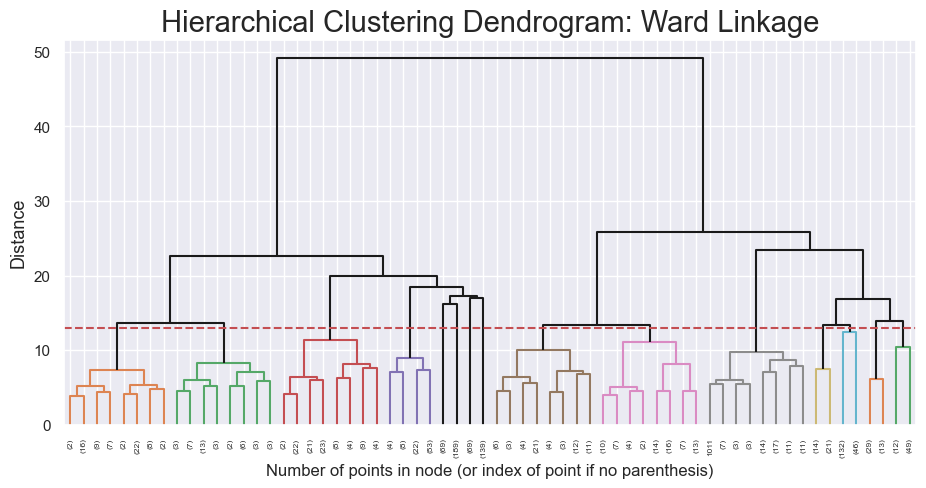

In [176]:
# Plot the corresponding dendrogram
sns.set()
fig = plt.figure(figsize=(11,5))
# The Dendrogram parameters need to be tuned
Y_THRESHOLD = 13
dendrogram(linkage_matrix, truncate_mode='level', p=5, color_threshold=Y_THRESHOLD, above_threshold_color='k')
    # You can play with 'truncate_mode' and 'p' define what level the dendrogram shows
    # above_threshold_color='k' forces black color for the lines above the threshold)
plt.hlines(Y_THRESHOLD, 0, 1000, colors="r", linestyles="dashed")
plt.title(f'Hierarchical Clustering Dendrogram: Ward Linkage', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.ylabel(f'Distance', fontsize=13)
plt.show()

In [177]:
# Performing HC
hclust = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=20)
hc_labels = hclust.fit_predict(df_centroids)
hc_labels

array([ 6,  6,  7, ..., 11, 11, 11])

In [178]:
df_centroids['merged_labels'] = hc_labels
df_centroids

Latitude  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name           Behavioral_Month_Cluster_Name             Value_Based_Cluster_Name                
High-Income East         Consistent low travelers\n(Use points) Avr|Dec Companion\r\n(Less travel on dec) Fly fanatics                -0.800379   
                                                                                                          High-Value Frequent Flyers  -0.855160   
                                                                                                          High-Value Low transactions -0.924640   
                                                                                                          Long-tenure                 -0.815406   
                                                                                                          New engaged                 -0.784981   
...                                                                                                                                         ...   
Low-Income West          Stable average travelers\n(Loyal)      Avr|Point Acumulator\r\n(No companions)   New engaged                 -0.186616   
                                                                Moderate travelers\r\n(Current average)   Fly fanatics                -0.213367   
                                                                                                          High-Value Frequent Flyers  -0.086938   
                                                                                                          Long-tenure                 -0.186024   
                                                                                                          New engaged                 -0.220781   

                                                                                                                                       Longitude  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name           Behavioral_Month_Cluster_Name             Value_Based_Cluster_Name                 
High-Income East         Consistent low travelers\n(Use points) Avr|Dec Companion\r\n(Less travel on dec) Fly fanatics                  0.583344   
                                                                                                          High-Value Frequent Flyers    0.399303   
                                                                                                          High-Value Low transactions   0.352217   
                                                                                                          Long-tenure                   0.454108   
                                                                                                          New engaged                   0.456025   
...                                                                                                                                          ...   
Low-Income West          Stable average travelers\n(Loyal)      Avr|Point Acumulator\r\n(No companions)   New engaged                  -0.609297   
                                                                Moderate travelers\r\n(Current average)   Fly fanatics                 -0.643435   
                                                                                                          High-Value Frequent Flyers   -0.549443   
                                                                                                          Long-tenure                  -0.589795   
                                                                                                          New engaged                  -0.079026   

                                                                                                                                         Income  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name           Behavioral_Month_Cluster_Name             Value_Based_Cluster_Name                
High

In [179]:
cluster_mapper = df_centroids['merged_labels'].to_dict()
inverse_cluster_mapper = {}

for key, value in cluster_mapper.items():
    # If the value isn't in the new dict yet, create a list
    if value not in inverse_cluster_mapper:
        inverse_cluster_mapper[value] = []
    
    # Append the original key to that list
    inverse_cluster_mapper[value].append(key)
inverse_cluster_mapper

{6: [('High-Income East',
   'Consistent low travelers\n(Use points)',
   'Avr|Dec Companion\r\n(Less travel on dec)',
   'Fly fanatics'),
  ('High-Income East',
   'Consistent low travelers\n(Use points)',
   'Avr|Dec Companion\r\n(Less travel on dec)',
   'High-Value Frequent Flyers'),
  ('High-Income East',
   'Consistent low travelers\n(Use points)',
   'Avr|Dec Companion\r\n(Less travel on dec)',
   'Long-tenure'),
  ('High-Income East',
   'Consistent low travelers\n(Use points)',
   'Avr|Dec Companion\r\n(Less travel on dec)',
   'New engaged'),
  ('High-Income East',
   'Formers Points accumulator\n(2020)',
   'Avr|Dec Companion\r\n(Less travel on dec)',
   'Fly fanatics'),
  ('High-Income East',
   'Formers Points accumulator\n(2020)',
   'Avr|Dec Companion\r\n(Less travel on dec)',
   'High-Value Frequent Flyers'),
  ('High-Income East',
   'Formers Points accumulator\n(2020)',
   'Avr|Dec Companion\r\n(Less travel on dec)',
   'Long-tenure'),
  ('High-Income East',
   'Forme

In [180]:
df_multi_perspective['merged_labels'] = df_multi_perspective.apply(
    lambda row: cluster_mapper[(row['Demographic_Cluster_Name'], row['Behavioral_Year_Cluster_Name'], row['Behavioral_Month_Cluster_Name'], row['Value_Based_Cluster_Name'])],
    axis=1
)


In [181]:
print(df_multi_perspective['merged_labels'].value_counts().sort_index()) 

merged_labels
0     3728
1      373
2      154
3      957
4      289
5      127
6      928
7      190
8       47
9     1759
10    1006
11     888
12     899
13     285
14    1021
15     973
16      64
17     906
18     978
19    1000
Name: count, dtype: int64


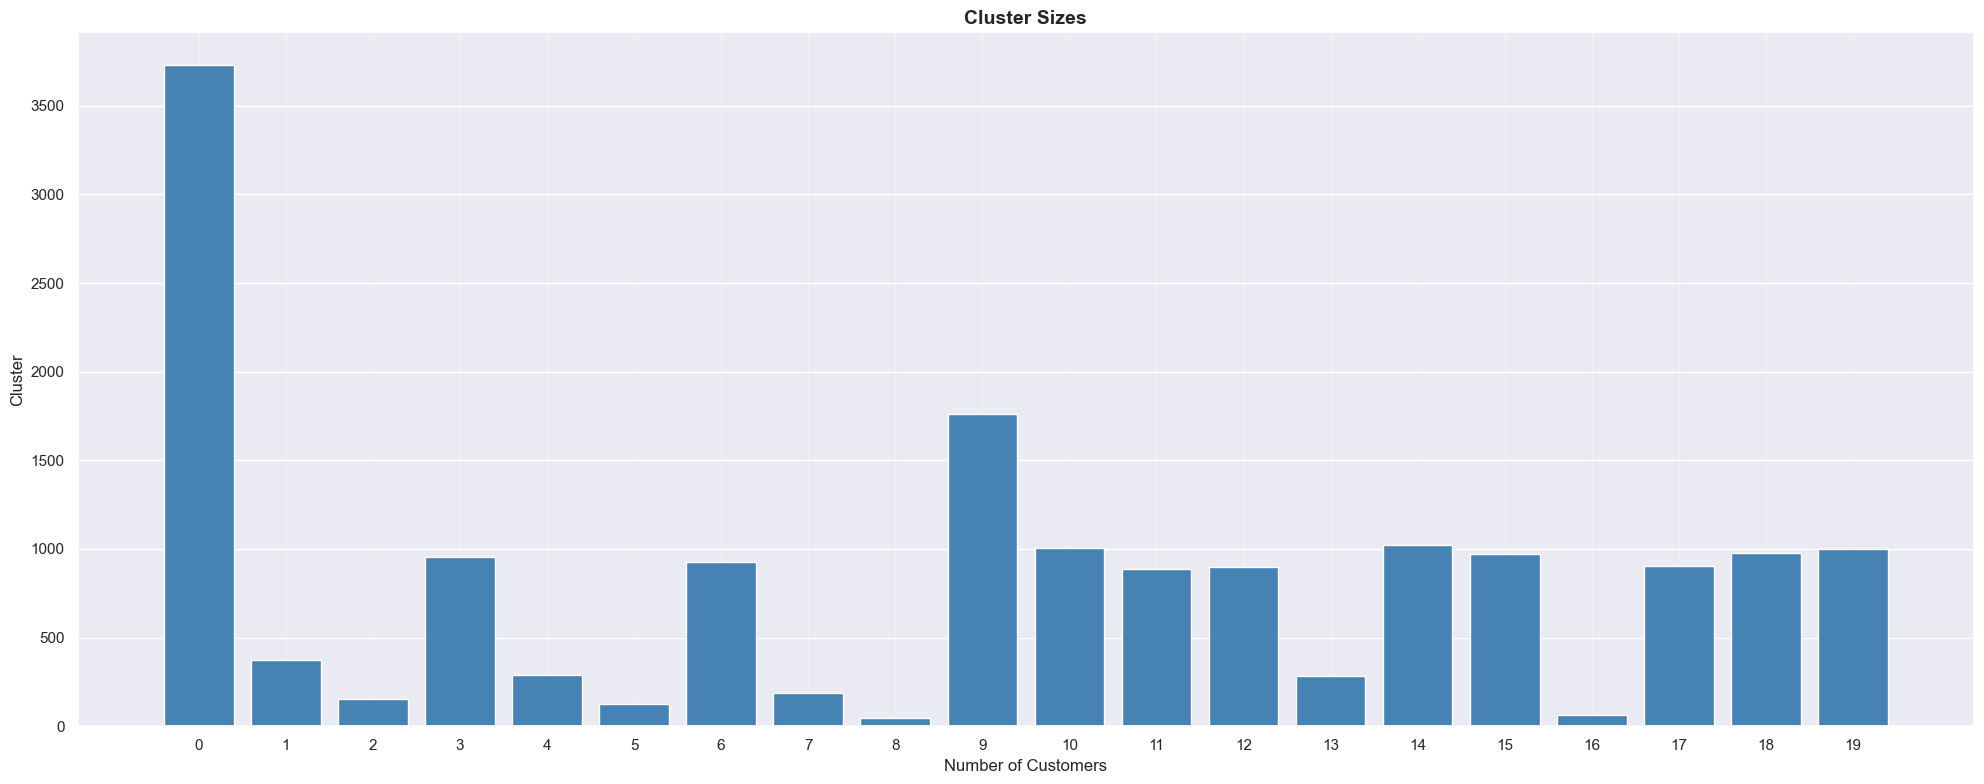

In [182]:
all_segments=df_centroids
fig, ax2 = plt.subplots( 1, figsize=(20, 8))

cluster_sizes = df_multi_perspective['merged_labels'].value_counts().sort_index()


ax2.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color="steelblue")
ax2.set_xlabel('Number of Customers', fontsize=12)
ax2.set_ylabel('Cluster', fontsize=12)
ax2.set_title('Cluster Sizes', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

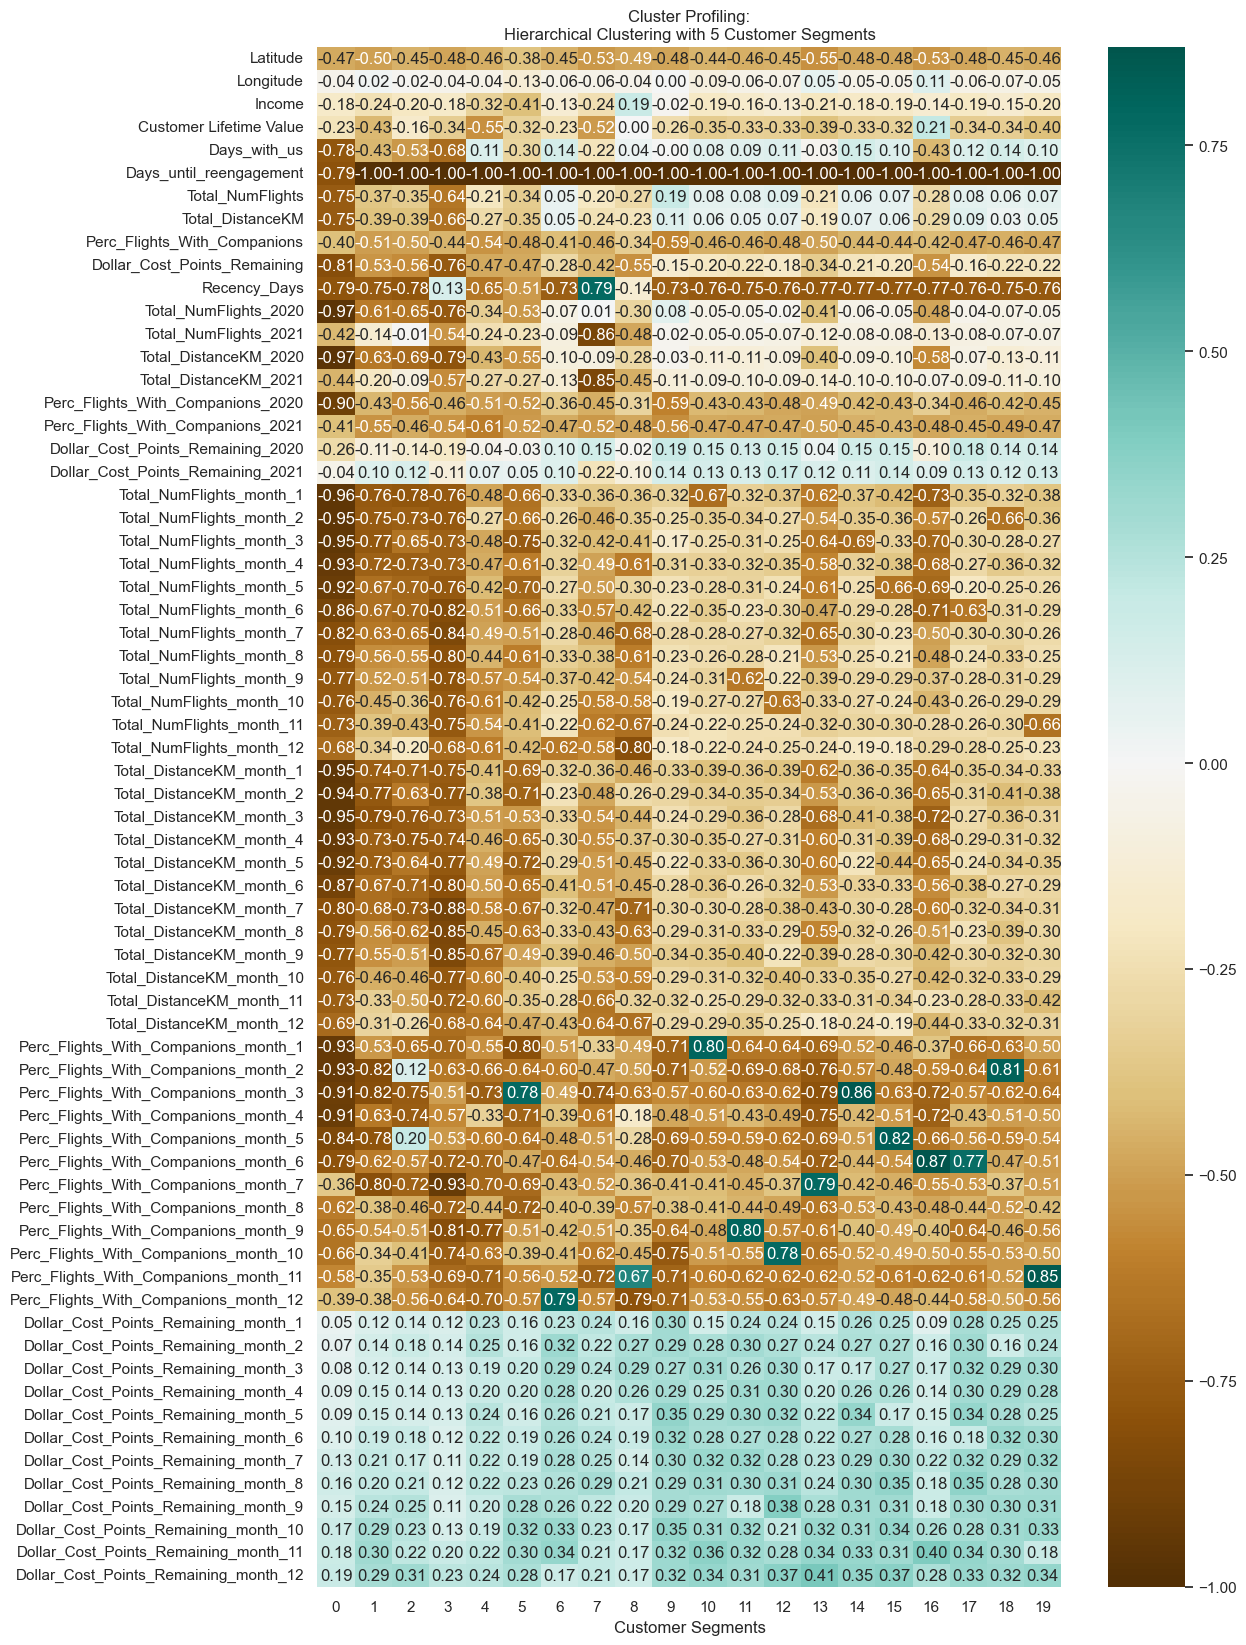

In [183]:
fig, ax = plt.subplots(figsize=(12, 20))

# Compute cluster profiles
km_profile = df_centroids.groupby('merged_labels').mean().T

# Rename cluster columns using your mapping


sns.heatmap(
    km_profile,
    center=0,
    annot=True,
    cmap="BrBG",
    fmt=".2f",
    ax=ax
)

ax.set_xlabel("Customer Segments")
ax.set_title("Cluster Profiling:\nHierarchical Clustering with 5 Customer Segments")
plt.show()

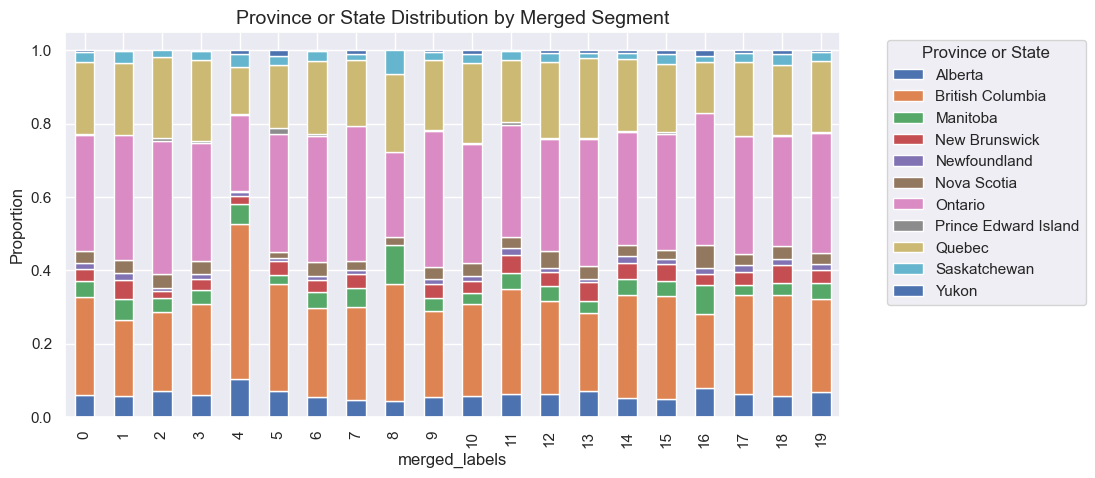

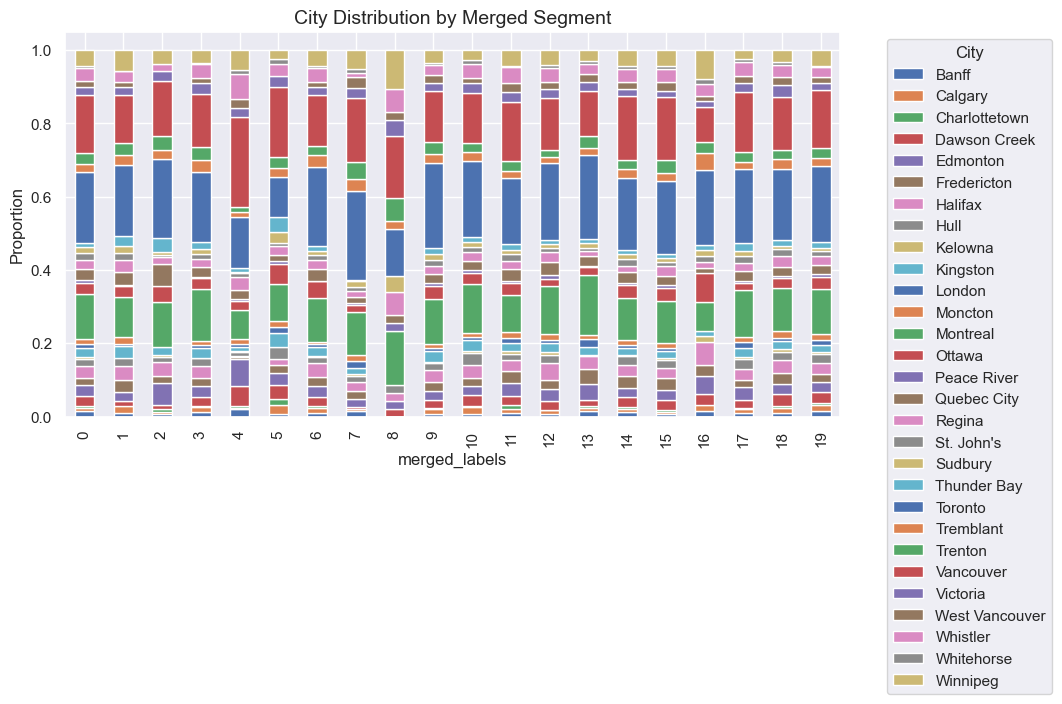

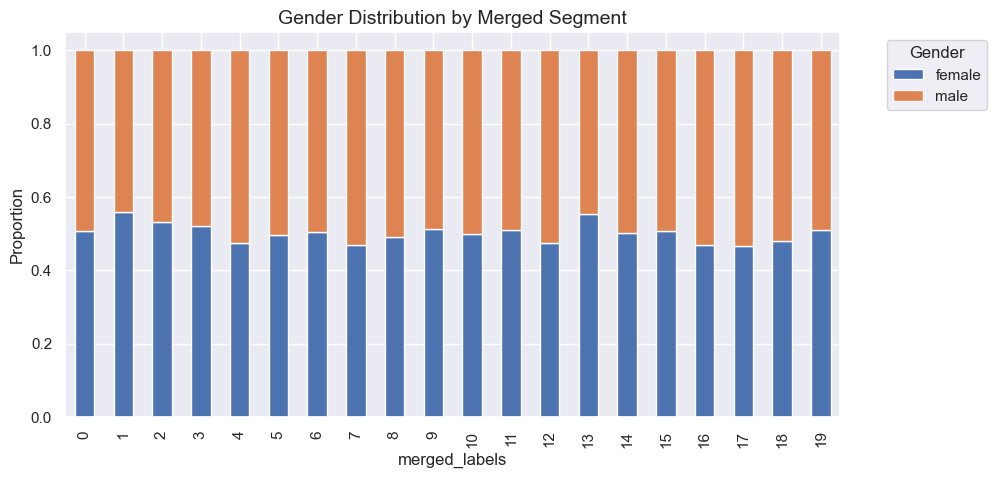

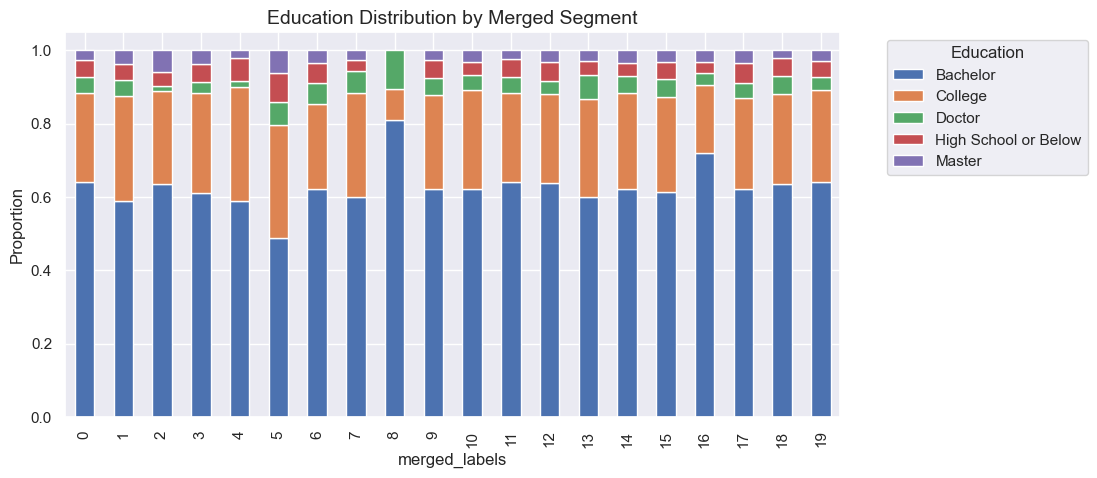

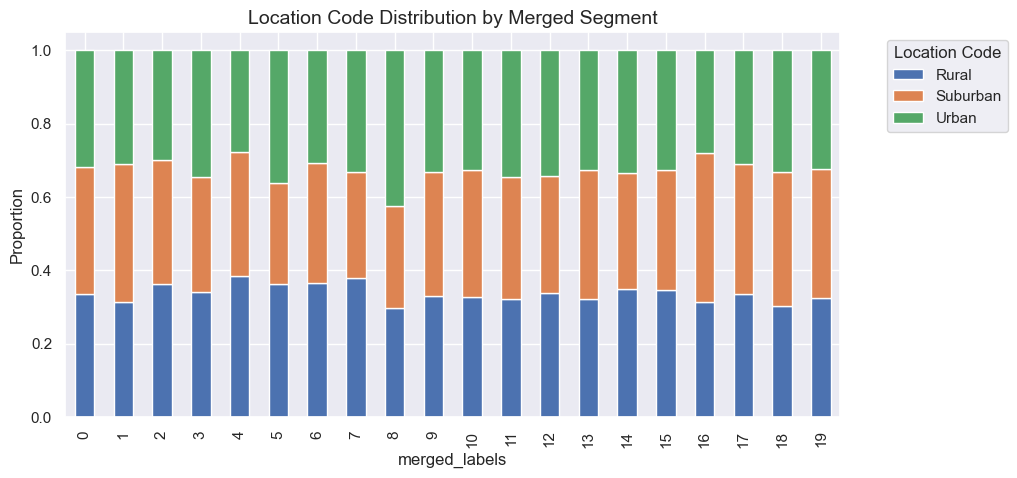

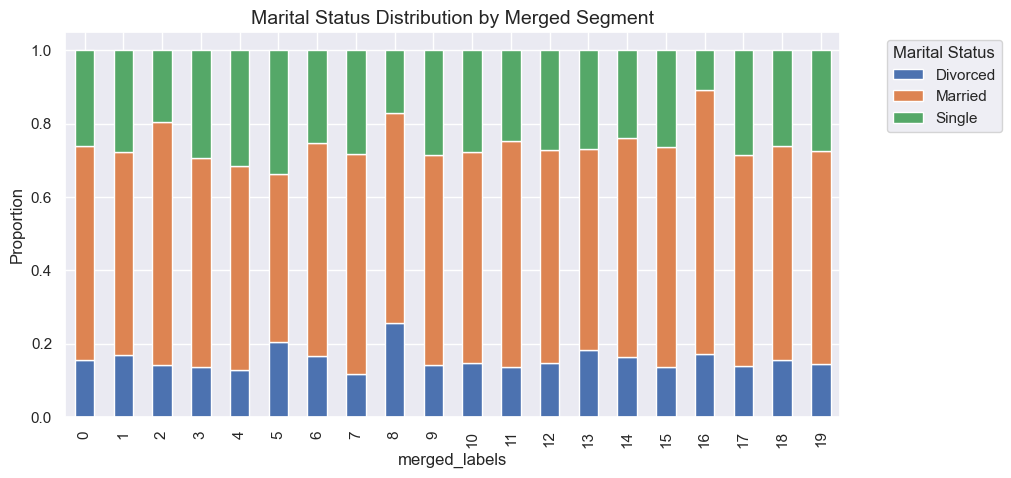

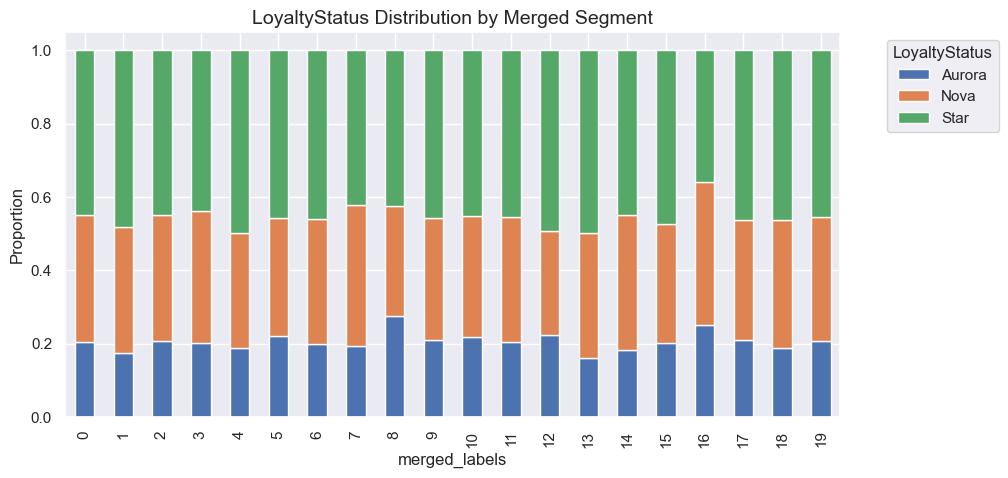

In [184]:
categorical = ['Province or State', 'City', 'Gender', 'Education', 
               'Location Code', 'Marital Status', 'LoyaltyStatus']

for col in categorical:
    pd.crosstab(df_multi_perspective['merged_labels'], 
                df_multi_perspective[col], 
                normalize='index').plot.bar(
        stacked=True,
        figsize=(10, 5)
    )
    plt.title(f"{col} Distribution by Merged Segment", fontsize=14)
    plt.ylabel("Proportion")
    plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

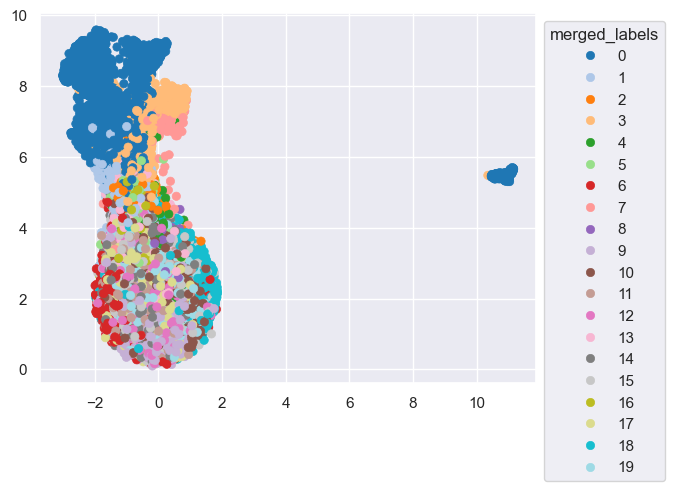

In [185]:
umap_original = umap.UMAP(n_neighbors = 300, random_state = 0).fit_transform(umap_for_modeling)
targets = df_multi_perspective['merged_labels']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1],palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

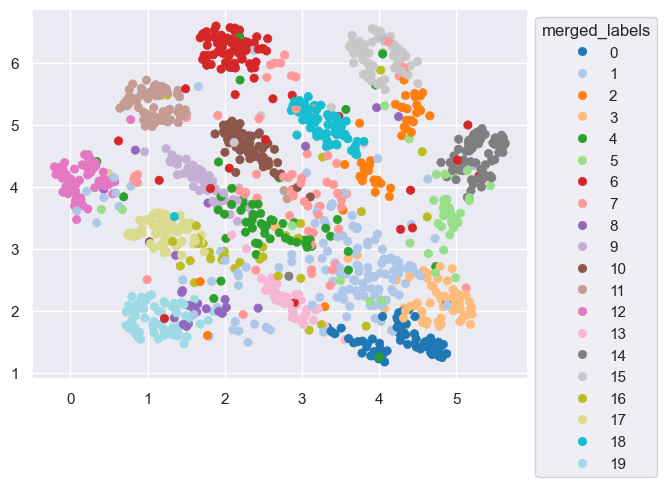

In [186]:
umap_original = umap.UMAP(n_neighbors = 300, random_state = 0).fit_transform(df_centroids.drop(columns=['merged_labels']))
targets = df_centroids['merged_labels']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1],palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [187]:
# full profiling (numerical and categorical)
# c-means
# autoencoder

In [209]:
X = umap_for_modeling.values

# Compute SST once (constant for all clusterings)
sst_per_feature = np.sum(np.square(X - X.mean(axis=0)), axis=0)
sst = np.sum(sst_per_feature, axis=0)

results = []

for n_clusters in range(2, 25):  # Test from 2 to 10 clusters
    kmclust = KMeans(n_clusters=n_clusters, init='k-means++', random_state=22)
    labels = kmclust.fit_predict(umap_for_modeling)
    
    # ---- SSW ----
    ssw = kmclust.inertia_
    
    # ---- SSB ----
    ssb_iter = []
    for i in np.unique(labels):
        X_k = X[labels == i]
        ssb_iter.append(X_k.shape[0] * np.square(X_k.mean(axis=0) - X.mean(axis=0)))
    ssb_per_feature = np.sum(ssb_iter, axis=0)
    ssb = np.sum(ssb_per_feature, axis=0)
    
    # ---- Silhouette ----
    sil_score = silhouette_score(X, labels)
    
    results.append({
        'num_clusters': n_clusters,
        'ssw (Lower is better, 0 to +∞)': ssw,
        'ssb (Higher is better, 0 to SST)': ssb,
        'silhouette_score (Higher is better, −1 to +1)': sil_score,
        'r2 (Higher is better, 0 to 1)': ssb / sst,
        
        
    })

df_cluster_metrics = pd.DataFrame(results)

In [210]:
df_cluster_metrics

,num_clusters,"ssw (Lower is better, 0 to +∞)","ssb (Higher is better, 0 to SST)","silhouette_score (Higher is better, −1 to +1)","r2 (Higher is better, 0 to 1)"
0,2,197862.773773,50332.526941,0.188655,0.202794
1,3,191319.654898,56875.771955,0.117924,0.229157
2,4,188369.999174,59825.312845,0.096898,0.241041
3,5,184686.180720,63509.156883,0.071870,0.255884
4,6,181950.298744,66245.049797,0.071420,0.266907
5,7,179621.492173,68573.893255,0.071578,0.276290
6,8,177554.813822,70640.488784,0.066200,0.284617
7,9,175703.898135,72491.408475,0.056702,0.292074
8,10,173982.723735,74212.652608,0.056128,0.299009
9,11,172722.098462,75473.211490,0.054399,0.304088


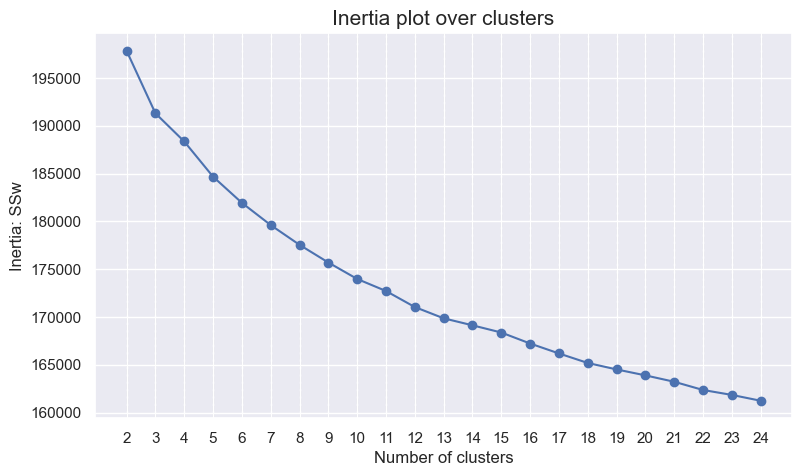

In [211]:
fig, ax = plt.subplots(figsize=(9,5))

range_clusters= list(range(2,25))
inertia= df_cluster_metrics['ssw (Lower is better, 0 to +∞)']
ax.plot(range_clusters, inertia, marker='o', zorder=2)
ax.set_xticks(list(range_clusters))

# draw vertical dashed background lines at each cluster number
for x in range_clusters:
    ax.axvline(x, color='lightgray', linestyle='--', linewidth=1, zorder=0, alpha=0.7)

ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters", size=15)

plt.show()

In [212]:
number_clusters = 15
kmclust = KMeans(n_clusters=number_clusters, init='k-means++', random_state=22)
km_labels = kmclust.fit_predict(umap_for_modeling)
km_labels

array([10, 10, 14, ...,  4,  8,  2], dtype=int32)

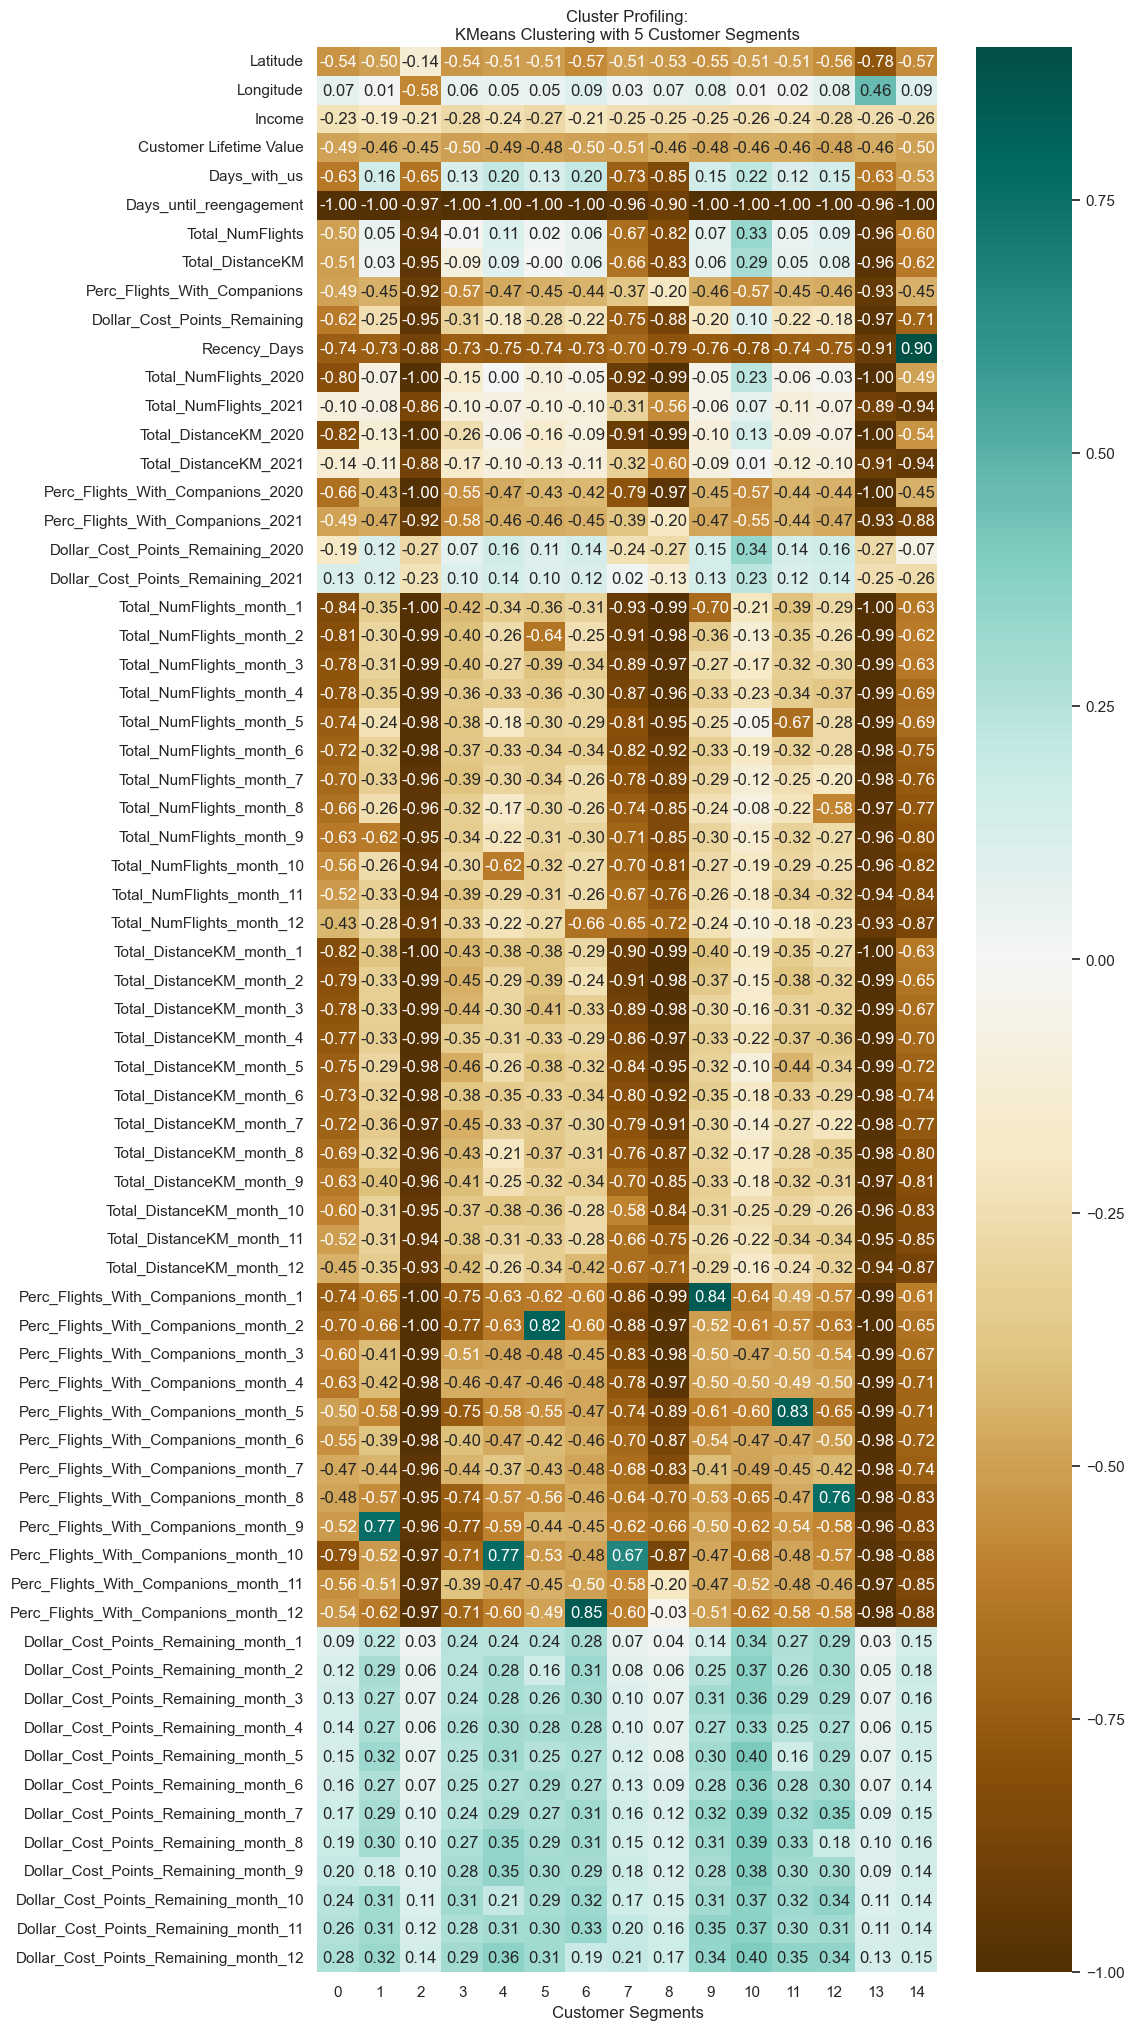

In [227]:
cluster_name_map = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6", 
    7: "7",
    8: "8", 
    9: "9",
    10: "10",
    11: "11",
    12: "12",
    13: "13",
    14: "14",

}

df_concat_km5 = pd.concat(
    (umap_for_modeling, pd.Series(km_labels, name='labels', index=umap_for_modeling.index)),
    axis=1
)

fig, ax = plt.subplots(figsize=(10, 25))

# Compute cluster profiles
km_profile = df_concat_km5.groupby('labels').mean().T

# Rename cluster columns using your mapping
km_profile = km_profile.rename(columns=cluster_name_map)

sns.heatmap(
    km_profile,
    center=0,
    annot=True,
    cmap="BrBG",
    fmt=".2f",
    ax=ax
)

ax.set_xlabel("Customer Segments")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 5 Customer Segments")
plt.show()

In [228]:
df_concat_km5['cluster_name'] = df_concat_km5['labels'].map(cluster_name_map)

In [229]:
df_concat_km5['cluster_name'].value_counts()

cluster_name
10    1783
3     1646
0     1351
13    1284
5     1121
9     1113
11    1111
6     1070
1     1054
12    1044
4     1034
2      922
8      739
14     699
7      601
Name: count, dtype: int64

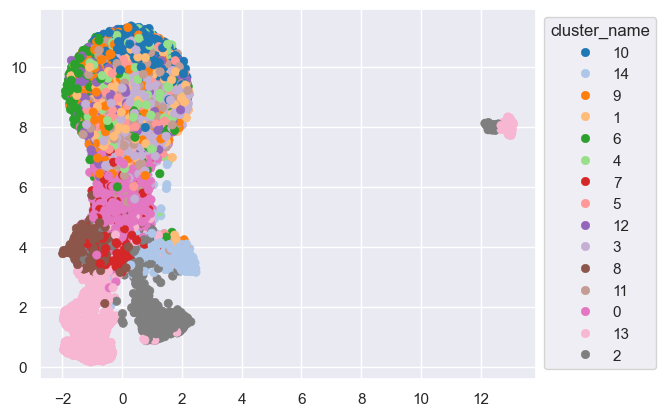

In [238]:
umap_original = umap.UMAP(n_neighbors = 50, random_state = 0).fit_transform(umap_for_modeling)
targets = df_concat_km5['cluster_name']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1], palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()